In [ ]:
#Display of tables
###################

import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dotenv import load_dotenv

load_dotenv()

conn = psycopg2.connect(
    host="localhost",
    port=5432,
    dbname="trading_platform",
    user="postgres",
    password=os.getenv("POSTGRES_PASSWORD")
)

query = "SELECT * FROM candles WHERE symbol = 'BTCUSDT' AND interval = '1m' ORDER BY open_time;"
df_btc_1m = pd.read_sql(query, conn)

print(df_btc_1m.shape)
df_btc_1m.head()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_8452\1617670325.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_btc_1m = pd.read_sql(query, conn)


(129600, 8)


,symbol,interval,open_time,open,high,low,close,volume
0,BTCUSDT,1m,2026-07-02 13:19:00,61782.00,61795.04,61772.00,61786.19,12.57043
1,BTCUSDT,1m,2026-07-02 13:20:00,61786.19,61792.36,61754.00,61774.85,33.94384
2,BTCUSDT,1m,2026-07-02 13:21:00,61774.85,61815.47,61756.11,61815.47,45.81144
3,BTCUSDT,1m,2026-07-02 13:22:00,61815.46,61824.45,61788.05,61822.87,30.72898
4,BTCUSDT,1m,2026-07-02 13:23:00,61822.87,61880.00,61810.00,61879.99,63.25718


count    129599.000000
mean          0.000003
std           0.000483
min          -0.014182
25%          -0.000191
50%           0.000000
75%           0.000189
max           0.021789
Name: return, dtype: float64


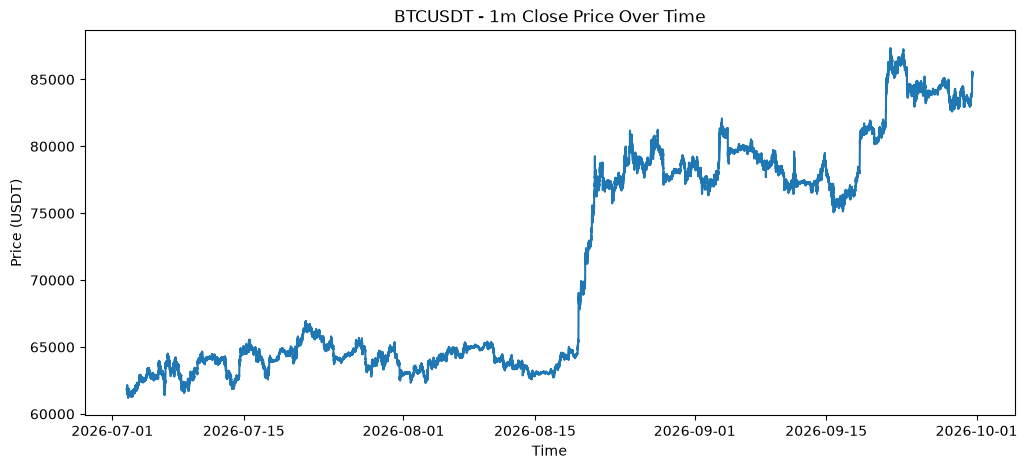

In [7]:
#Volatility Analysis
#################

df_btc_1m["return"] = df_btc_1m["close"].pct_change()

print(df_btc_1m["return"].describe())

plt.figure(figsize=(12, 5))
plt.plot(df_btc_1m["open_time"], df_btc_1m["close"])
plt.title("BTCUSDT - 1m Close Price Over Time")
plt.xlabel("Time")
plt.ylabel("Price (USDT)")
plt.show()

In [ ]:
#Missing Data/gap check

df_btc_1m["time_diff"] = df_btc_1m["open_time"].diff()

gaps = df_btc_1m[df_btc_1m["time_diff"] > pd.Timedelta(minutes=1)]
print(f"Number of gaps: {len(gaps)}")
gaps[["open_time", "time_diff"]]

Number of gaps: 1


,open_time,time_diff
43200,2026-09-24 21:19:00,8 days 04:28:00


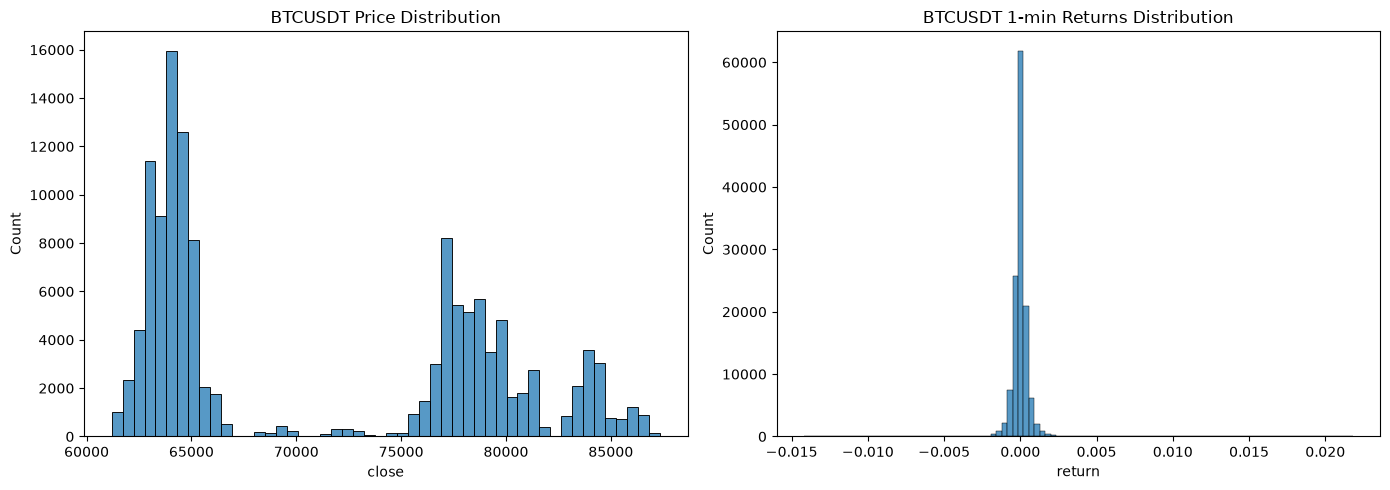

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_btc_1m["close"], bins=50, ax=axes[0])
axes[0].set_title("BTCUSDT Price Distribution")

sns.histplot(df_btc_1m["return"].dropna(), bins=100, ax=axes[1])
axes[1].set_title("BTCUSDT 1-min Returns Distribution")

plt.tight_layout()
plt.show()

direction
0    67955
1    61645
Name: count, dtype: int64
direction
0    0.524344
1    0.475656
Name: proportion, dtype: float64


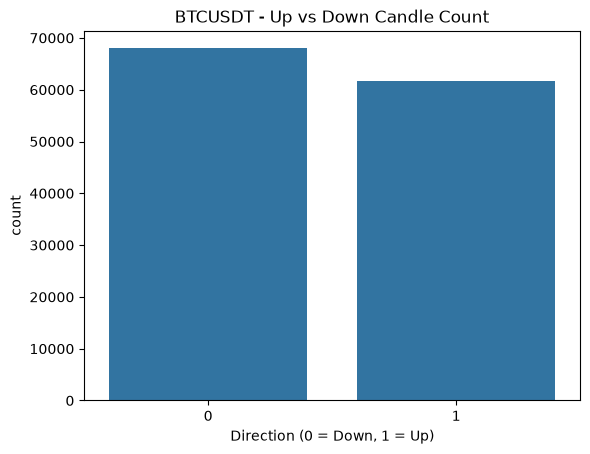

In [9]:
df_btc_1m["direction"] = (df_btc_1m["return"] > 0).astype(int)

print(df_btc_1m["direction"].value_counts())
print(df_btc_1m["direction"].value_counts(normalize=True))

sns.countplot(x="direction", data=df_btc_1m)
plt.title("BTCUSDT - Up vs Down Candle Count")
plt.xlabel("Direction (0 = Down, 1 = Up)")
plt.show()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_8452\3954093012.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_eth_1m = pd.read_sql(query_eth, conn)
C:\Users\lenovo\AppData\Local\Temp\ipykernel_8452\3954093012.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_bnb_1m = pd.read_sql(query_bnb, conn)


          BTC       ETH       BNB
BTC  1.000000  0.834945  0.719547
ETH  0.834945  1.000000  0.725544
BNB  0.719547  0.725544  1.000000


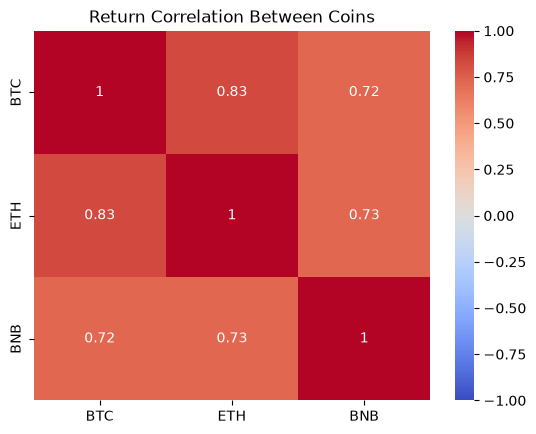

In [10]:
query_eth = "SELECT * FROM candles WHERE symbol = 'ETHUSDT' AND interval = '1m' ORDER BY open_time;"
df_eth_1m = pd.read_sql(query_eth, conn)
df_eth_1m["return"] = df_eth_1m["close"].pct_change()

query_bnb = "SELECT * FROM candles WHERE symbol = 'BNBUSDT' AND interval = '1m' ORDER BY open_time;"
df_bnb_1m = pd.read_sql(query_bnb, conn)
df_bnb_1m["return"] = df_bnb_1m["close"].pct_change()

returns_combined = pd.DataFrame({
    "BTC": df_btc_1m["return"],
    "ETH": df_eth_1m["return"],
    "BNB": df_bnb_1m["return"]
})

correlation_matrix = returns_combined.corr()
print(correlation_matrix)

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Return Correlation Between Coins")
plt.show()